Plot skewness and Kurtosis of samples of inter-arrival and service distribution based on their moments.

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from Sampling.Save_Combine_Read_for_CSV_files import Load_Samples_from_file
from Training.Class_training import NN_for_Queue


In [2]:
##### Parameters
n_max = 10           # The highest order of moments
Lmax = 500           # The maximum queue length
m_max = 15           # The maximum order of PH-representation (alpha, T)
input_dim = 2*n_max  # DNN input dimension: arrival n_max + service n_max


In [3]:
def normalize_moments_to_mean_one(moms):
    """
    moms: shape (N, >=4), raw moments m1, m2, m3, m4
    returns: normalized moments with mean = 1
    """
    m1 = moms[:, 0]
    moms_norm = moms.copy()

    # m_k(X / m1) = m_k(X) / m1^k
    for k in range(moms.shape[1]):
        moms_norm[:, k] = moms[:, k] / (m1 ** (k + 1)) # normalize by dividing by (m1 ** (k + 1))

    return moms_norm


In [4]:
def skew_kurt_from_raw_moments(moms):
    """
    moms: shape (N, >=4), raw moments with mean already normalized to 1
    """
    m1, m2, m3, m4 = moms[:,0], moms[:,1], moms[:,2], moms[:,3]
    
    var = m2 - m1**2
    std = np.sqrt(var)

    mu3 = m3 - 3*m2*m1 + 2*m1**3 # third central moment
    mu4 = m4 - 4*m3*m1 + 6*m2*m1**2 - 3*m1**4 # fourth central moment

    skew = mu3 / std**3 # Skewness
    kurt = mu4 / std**4 # Kurtosis

    return skew, kurt

In [5]:
def summary_table(x, name='skewness'):
    summary = {
        'Count': len(x),
        'Mean': np.mean(x),
        'Std': np.std(x, ddof=1),
        'Min': np.min(x),
        '10%': np.quantile(x, 0.10),
        '25%': np.quantile(x, 0.25),
        'Median': np.quantile(x, 0.50),
        '75%': np.quantile(x, 0.75),
        '90%': np.quantile(x, 0.90),
        'Max': np.max(x)
    }
    return pd.DataFrame(summary, index=[name])


In [6]:
# function to plot skew and kurt given K and queue_type
def plot_skew_kurt(K, queue_type):

    # load samples
    DNN_net = NN_for_Queue(
        queue_type=queue_type, n_max=n_max, Lmax=Lmax, m_max=m_max, input_dim=input_dim, num_classes=Lmax
    )

    df_all_K = DNN_net.Load_and_Merge_All_Samples_for_K(K) 

    # sample shape
    print("Total samples for K=", K, ":", df_all_K.shape[0])

    # Break samples into Moments, stationary distribution, and rho blocks
    Moments_all, Stationary_all, rho_all = Load_Samples_from_file(n_max, Lmax, df_all_K)
    # convert to float
    Moments_all = Moments_all.astype(float)
    Stationary_all = Stationary_all.astype(float)

    Moments_all_real = np.exp(Moments_all) -1 # transfer back to moments
    Moments_arrival = Moments_all_real[:, :n_max] # obtain arrival monents
    Moments_service = Moments_all_real[:, n_max:] # obtain service moments
    # 1. mean normalization
    mom_arr_n = normalize_moments_to_mean_one(Moments_arrival)
    mom_ser_n = normalize_moments_to_mean_one(Moments_service)
    # 2. skewness & kurtosis
    skew_a, kurt_a = skew_kurt_from_raw_moments(mom_arr_n)
    skew_s, kurt_s = skew_kurt_from_raw_moments(mom_ser_n)  
    plt.figure(figsize=(6,5))
    plt.scatter(skew_a, kurt_a, alpha=0.5, label='Interarrival')
    plt.scatter(skew_s, kurt_s, alpha=0.5, label='Service')
    plt.xlabel('Skewness')
    plt.ylabel('Kurtosis')
    plt.xlim(-2,10)
    plt.ylim(0,100)
    plt.title(f'$K$={K}, Queue Type={queue_type}')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Processing K=1, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 1 : 482270


C:\Users\he201\AppData\Local\Temp\ipykernel_3896\4085711512.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\he201\anaconda3\envs\GIGKQueue\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


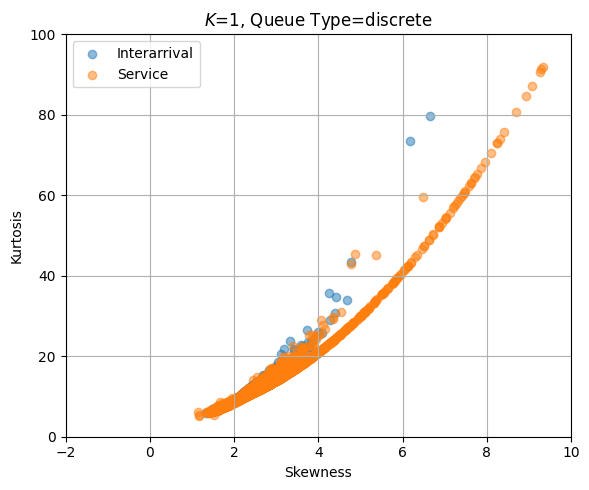

Processing K=1, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 1 : 530025


C:\Users\he201\AppData\Local\Temp\ipykernel_3896\4085711512.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\he201\anaconda3\envs\GIGKQueue\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


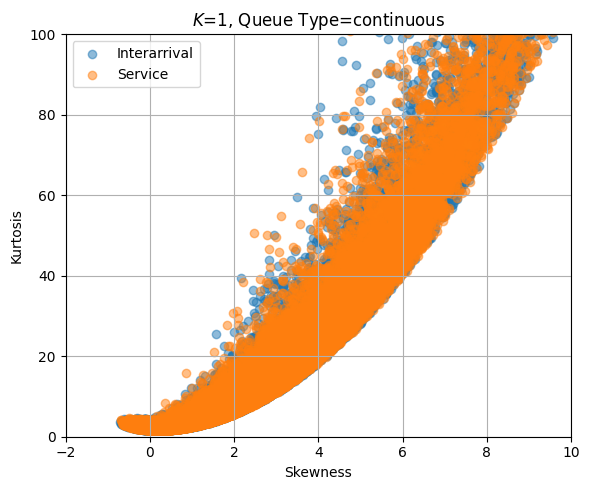

Processing K=2, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 2 : 89216


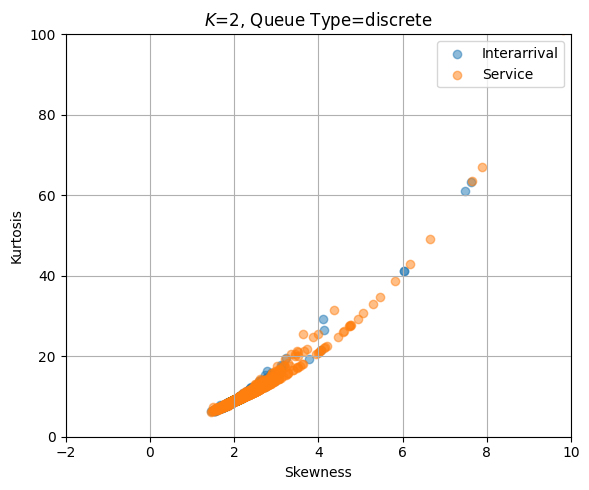

Processing K=2, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 2 : 101025


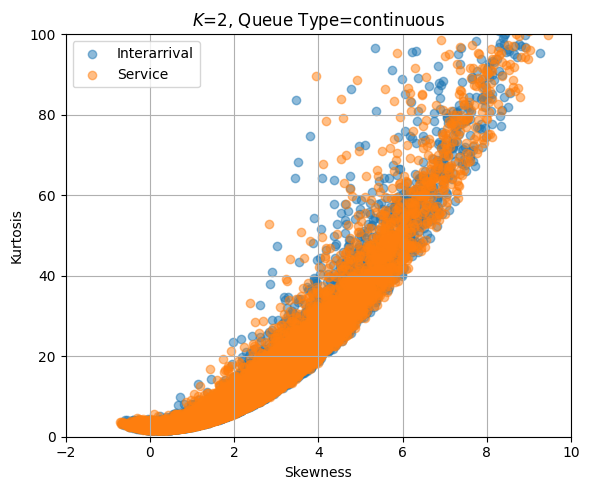

Processing K=3, queue_type=discrete
The queue type is discrete
load samples: queue type is discrete
Total samples for K= 3 : 42126


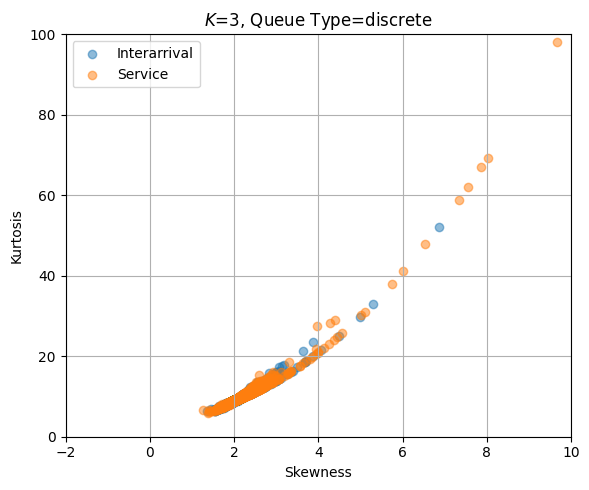

Processing K=3, queue_type=continuous
The queue type is continuous
load samples: queue type is continuous
Total samples for K= 3 : 68219


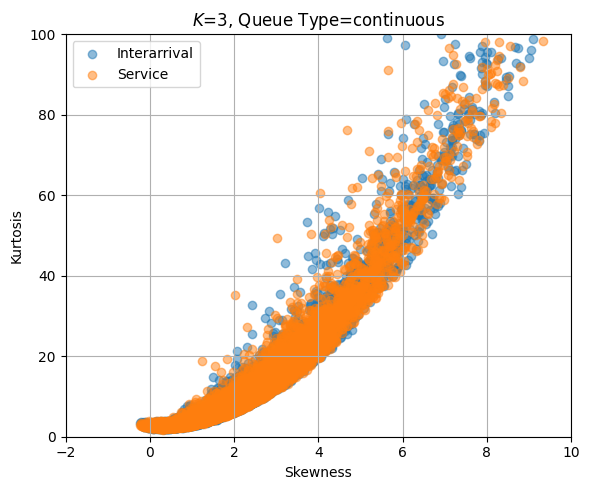

In [7]:
# loop over K and queue_type for all samples
for K in [1,2,3]:
    for queue_type in ['discrete', 'continuous']:
        print(f"Processing K={K}, queue_type={queue_type}")
        plot_skew_kurt(K, queue_type)

